# India Natural Disaster Events

This notebook looks into the data on Hyderabad, India from the MET Office dataset and attempts to make links with the data in the EMDAT dataset.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import glob

## Preprocessing

In [2]:
# loading EMDAT and GDIS dataset
df_EMDAT = pd.read_excel("EMDAT_dataset.xlsx")
df_GDIS = pd.read_csv("pend-gdis-1960-2018-disasterlocations.csv")

# combining GDIS and EMDAT data  
df_GDIS["disasterno"] = df_GDIS["disasterno"] + "-" + df_GDIS["iso3"]

df_combined = df_EMDAT.merge(
    df_GDIS[["disasterno", "latitude", "longitude"]],
    left_on="DisNo.",
    right_on="disasterno",
    how="left"
)

In [3]:
# defining columns and locations for MET office data
columns = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Temperature",
    "Precipitation",
    "U-wind",
    "V-wind"
]

india = "17.36N_78.5E"

# loading MET office dataset 
files = glob.glob("../visualisation/dataset/*.csv")
dfs = []

for file in files:
    if india in file:
        df = pd.read_csv(file, header=None, names=columns)
        df["location"] = file.split("/")[-1].replace(".csv", "")
        dfs.append(df)

df_METOFFICE = pd.concat(dfs, ignore_index=True)
df_METOFFICE["datetime"] = pd.to_datetime(df_METOFFICE[["Year", "Month", "Day", "Hour"]])

## Weather in India

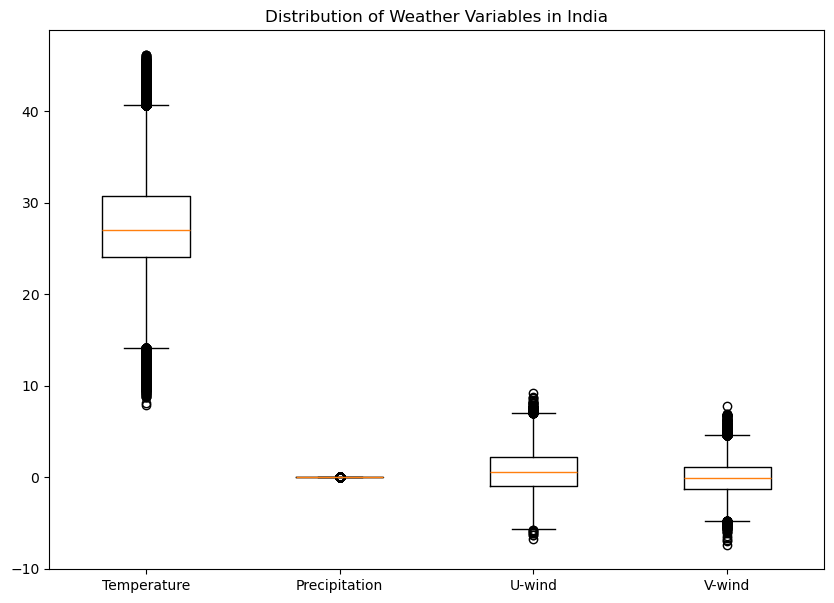

        Temperature_C  Precipitation    U-wind    V-wind
Median          27.01       0.000000  0.544380 -0.143355
IQR              6.64       0.000005  3.180505  2.339300


In [10]:
# converting temperature to celcius for better axis scale 
df_METOFFICE["Temperature_C"] = df_METOFFICE["Temperature"] - 273.15

# plotting all atmospheric variables on a singular plot
fig = plt.figure(figsize = (10, 7))
plt.boxplot([
    df_METOFFICE["Temperature_C"], 
    df_METOFFICE["Precipitation"],
    df_METOFFICE["U-wind"],
    df_METOFFICE["V-wind"]
])

plt.xticks([1, 2, 3, 4], ["Temperature", "Precipitation", "U-wind", "V-wind"])
plt.title("Distribution of Weather Variables in India")
plt.show()

# calculating median and iqr for variables 
summary_stats = df_METOFFICE[["Temperature_C", "Precipitation", "U-wind", "V-wind"]].agg(
    ["median", lambda x: x.quantile(0.75) - x.quantile(0.25)]
)
 
summary_stats.index = ["Median", "IQR"]
print(summary_stats)

Text(0.5, 1.0, 'Distribution of Temperature (Celcius) in India')

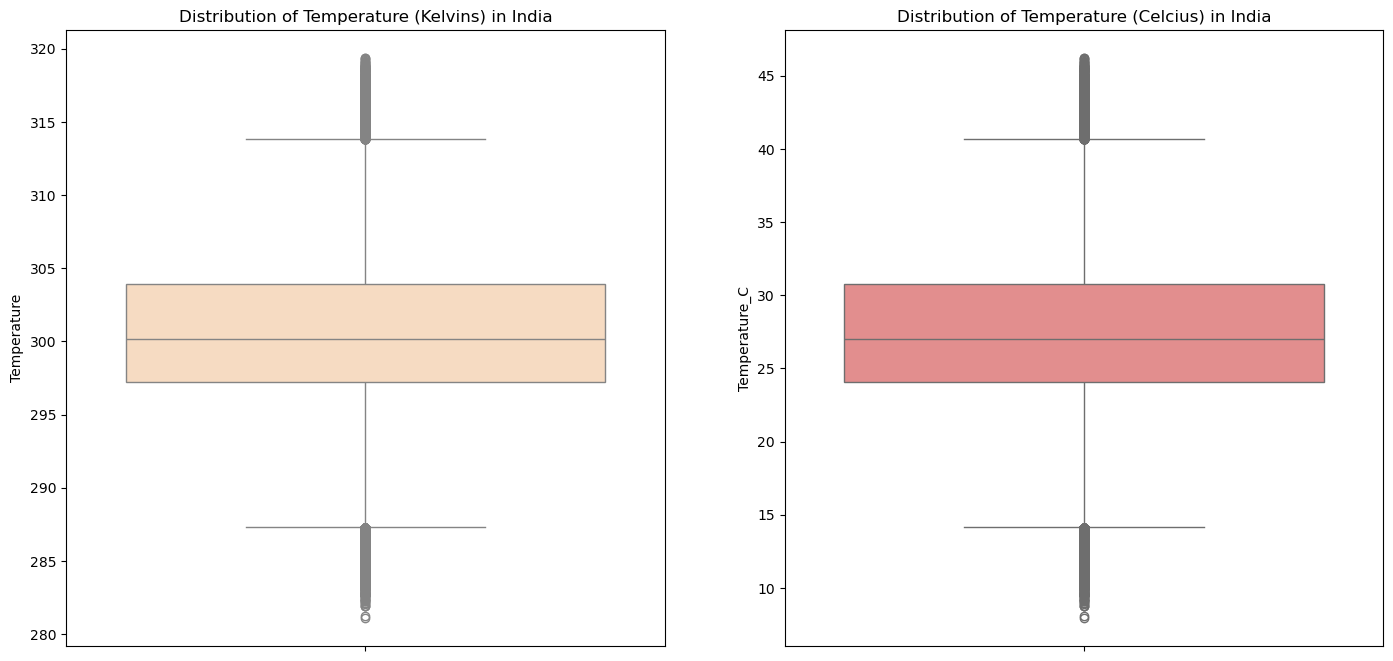

In [5]:
# separate box plots for each individual atmospheric variable 
# --- temperature ---
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.boxplot(y=df_METOFFICE["Temperature"], ax=axes[0], color="peachpuff")
axes[0].set_title("Distribution of Temperature (Kelvins) in India")

sns.boxplot(y=df_METOFFICE["Temperature_C"], ax=axes[1], color="lightcoral")
axes[1].set_title("Distribution of Temperature (Celcius) in India")

Median:  -18.420680743952367
IQR:  6.2889360463794635


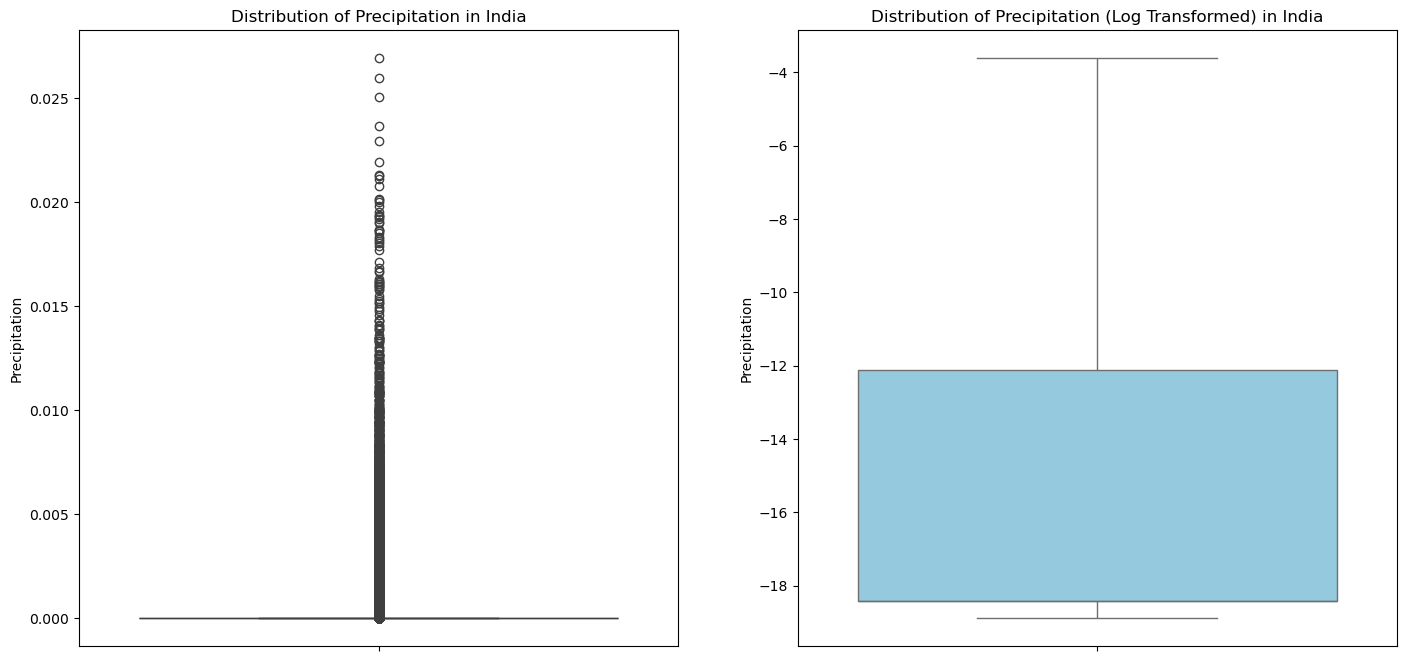

In [11]:
# --- precipitation ---
log_precipitation = np.log(df_METOFFICE["Precipitation"] + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.boxplot(y=df_METOFFICE["Precipitation"], ax=axes[0])
axes[0].set_title("Distribution of Precipitation in India")

sns.boxplot(y=log_precipitation, ax=axes[1], color="skyblue")
axes[1].set_title("Distribution of Precipitation (Log Transformed) in India")

# printing statistics (iqr, median) for log transformed precipitation
median_precipitation = log_precipitation.median()
q1_precipitation = log_precipitation.quantile(0.25)
q3_precipitation = log_precipitation.quantile(0.75)
iqr_precipitation = q3_precipitation - q1_precipitation

print("Median: ", median_precipitation)
print("IQR: ", iqr_precipitation)

Text(0.5, 1.0, 'Distribution of V-wind (m/s) in India)')

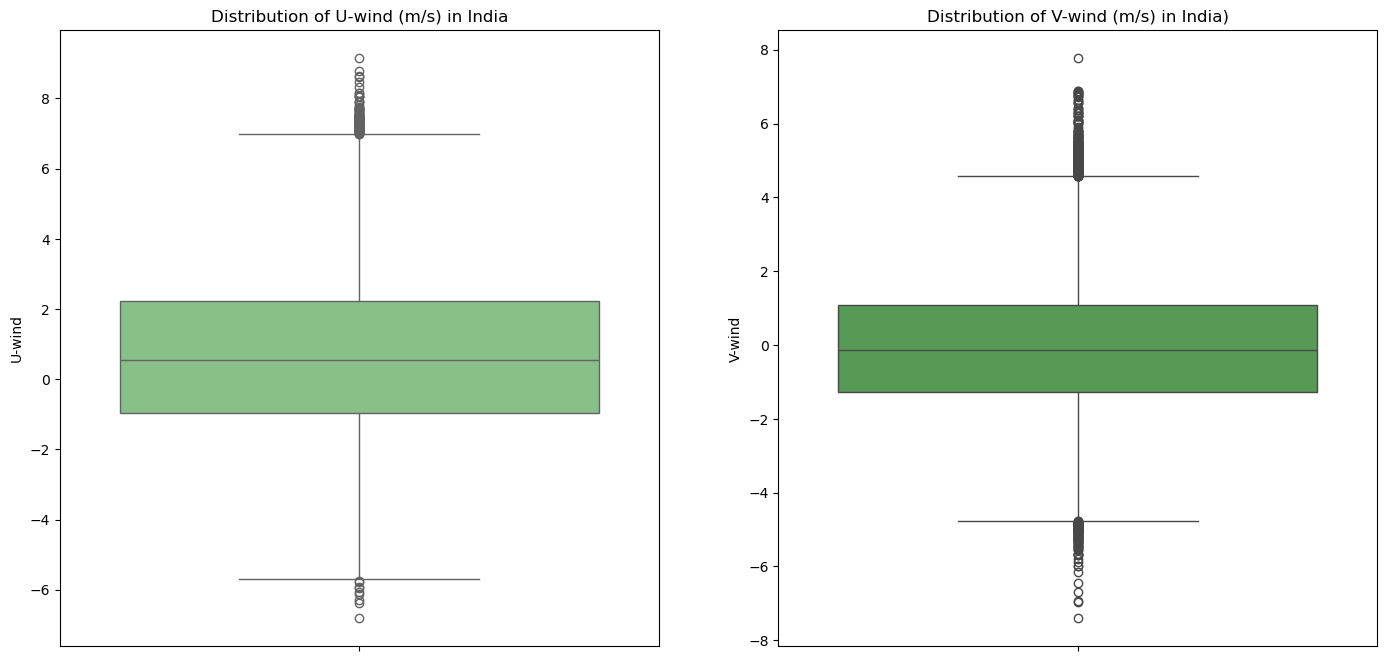

In [7]:
# --- wind speeds ---
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.boxplot(y=df_METOFFICE["U-wind"], ax=axes[0], color="#7FC97F")
axes[0].set_title("Distribution of U-wind (m/s) in India")

sns.boxplot(y=df_METOFFICE["V-wind"], ax=axes[1], color="#4CA649")
axes[1].set_title("Distribution of V-wind (m/s) in India)")

Text(0.5, 1.0, 'Distribution of Temperature in India (Celcius)')

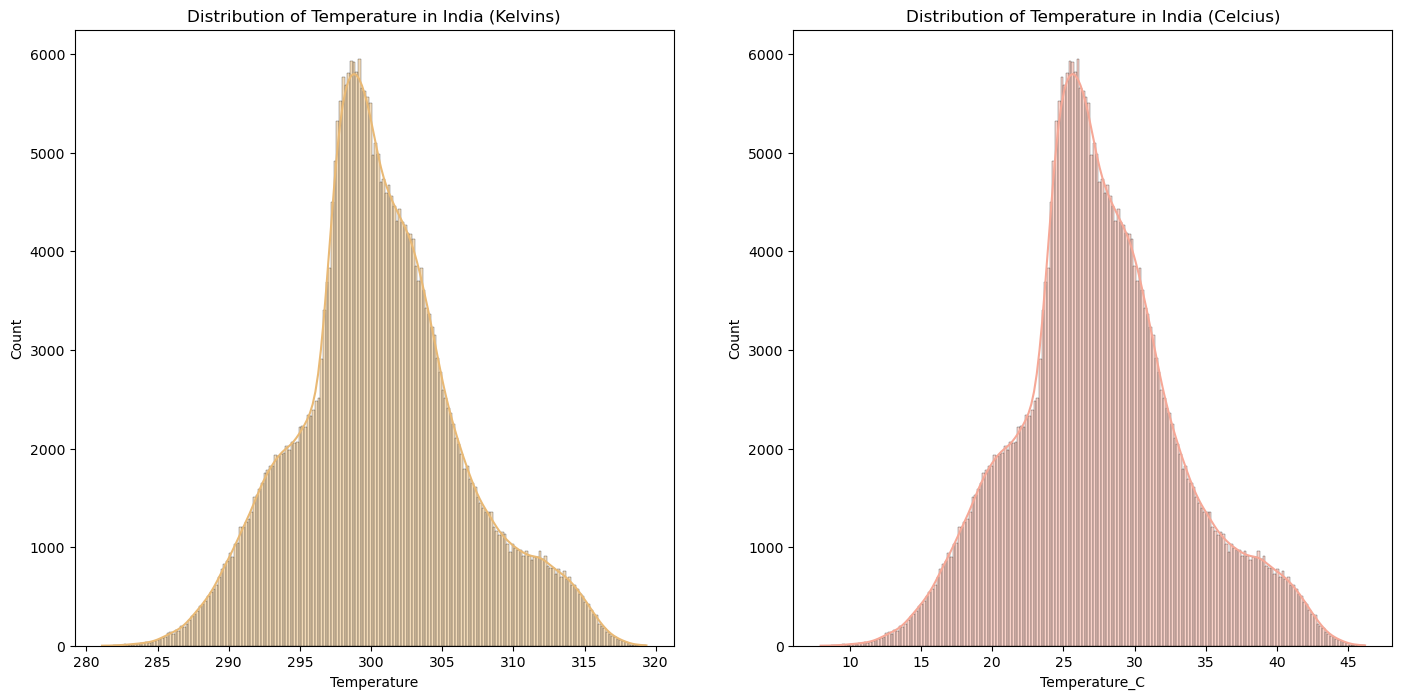

In [8]:
# histograms looking into the distribution of each variable 
# --- temperature ---
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.histplot(df_METOFFICE["Temperature"], kde=True, ax=axes[0], color="#E9B975")
axes[0].set_title("Distribution of Temperature in India (Kelvins)")

sns.histplot(df_METOFFICE["Temperature_C"], kde=True, ax=axes[1], color="#F6A897")
axes[1].set_title("Distribution of Temperature in India (Celcius)")

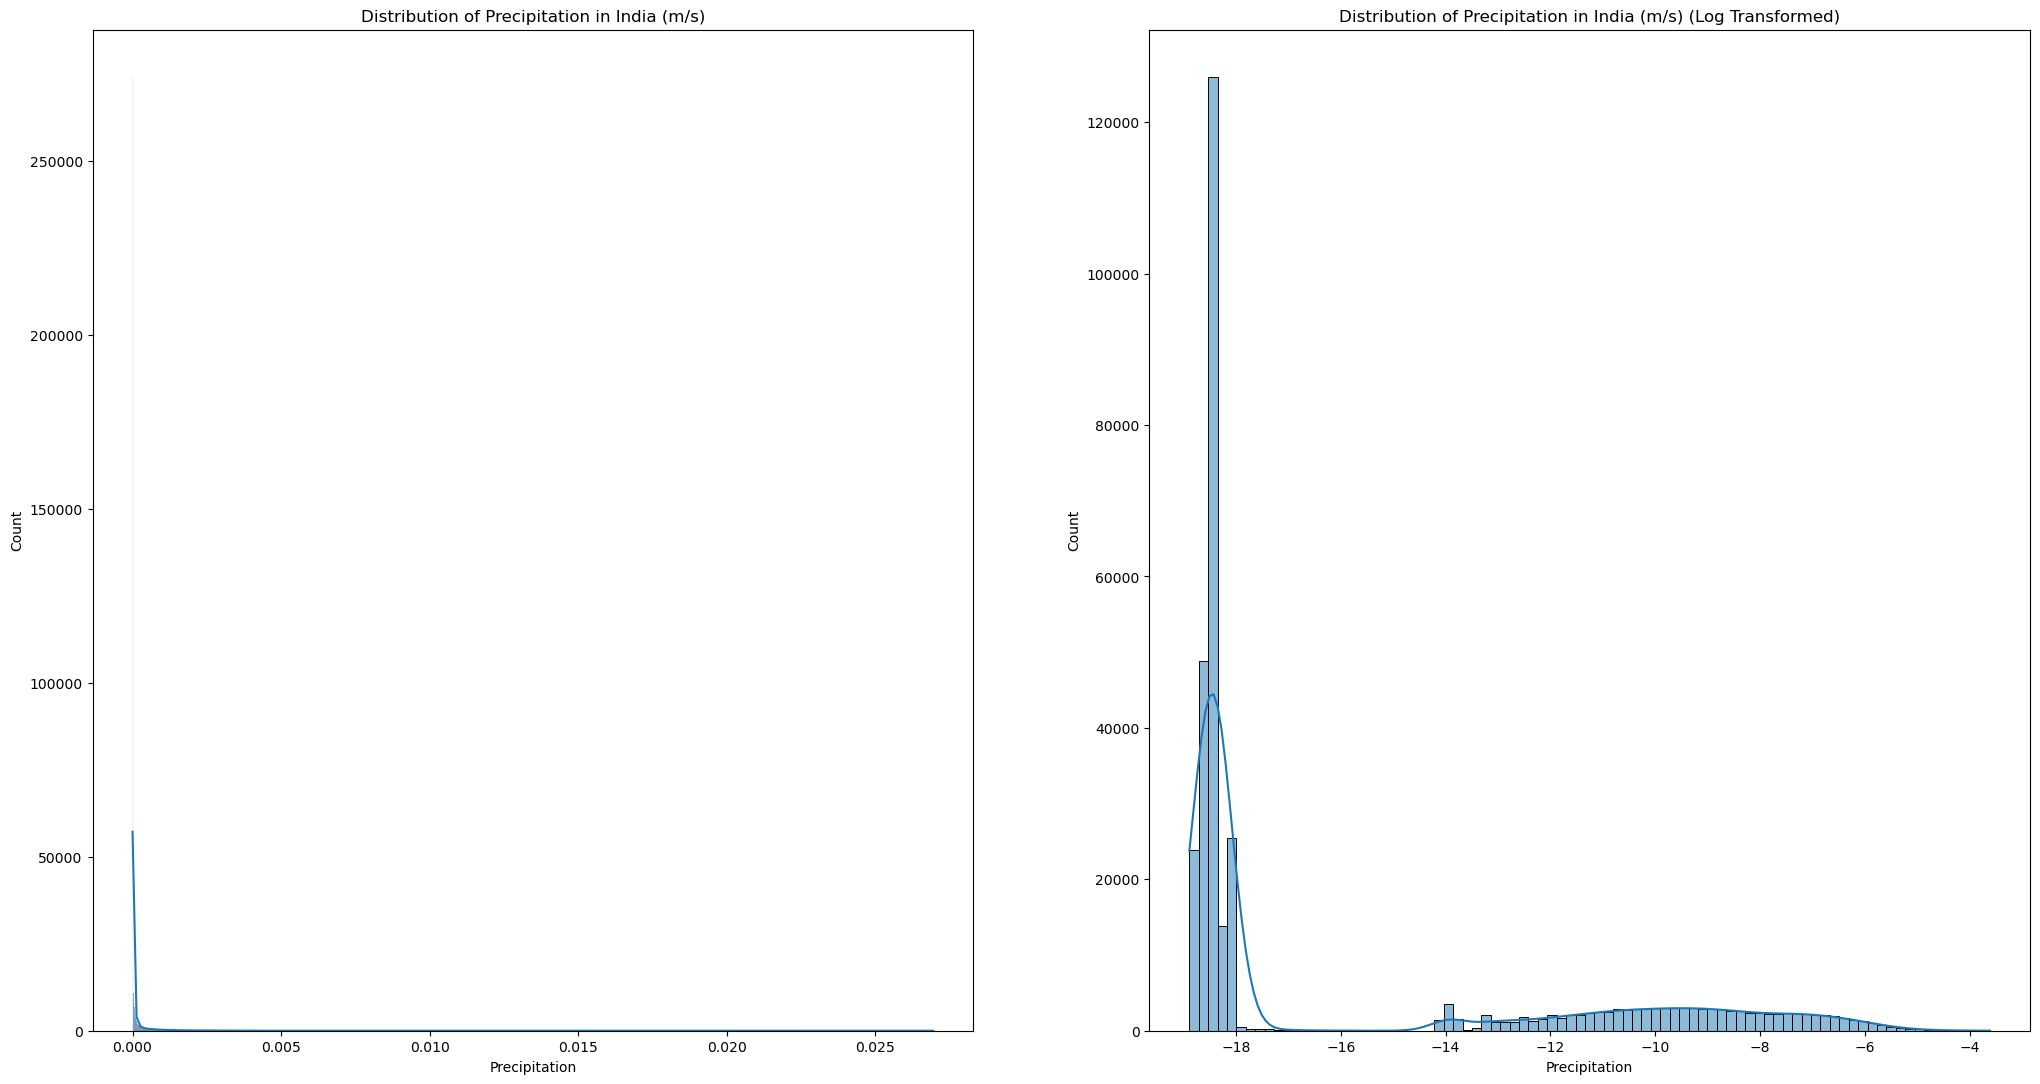

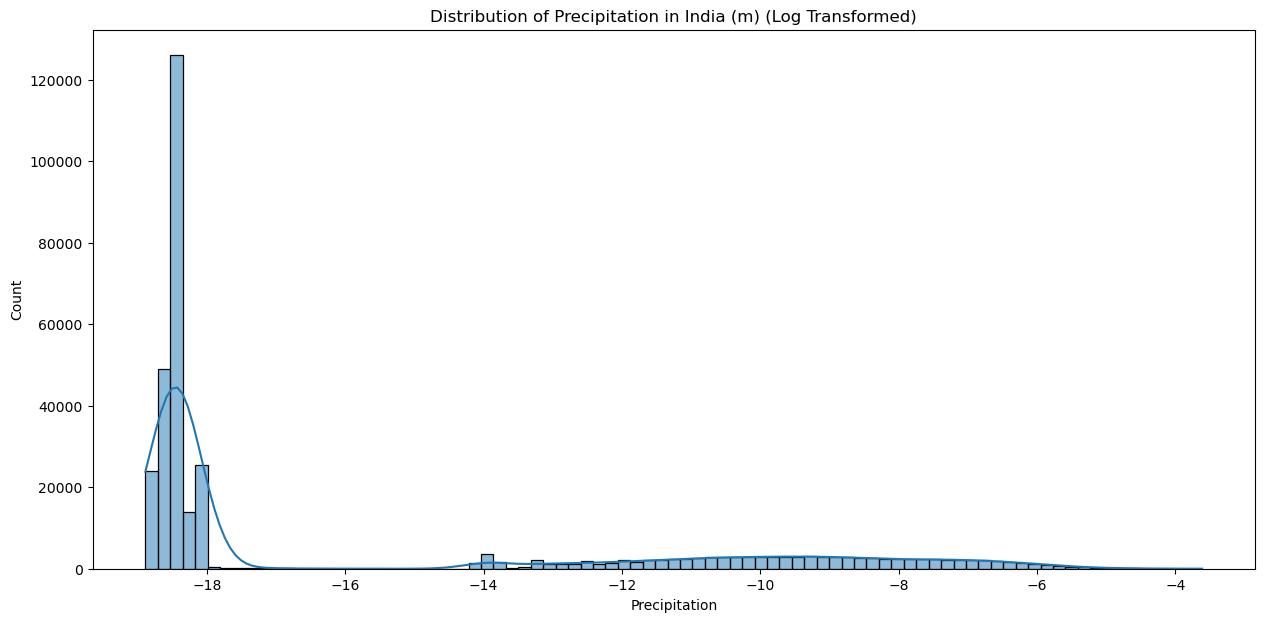

In [9]:
# --- precipitation ---
fig, axes = plt.subplots(1, 2, figsize=(25, 13))
sns.histplot(df_METOFFICE["Precipitation"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Precipitation in India (m/s)")

sns.histplot(log_precipitation, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Precipitation in India (m/s) (Log Transformed)")

# plotting just log transformed data
plt.figure(figsize=(15, 7))
sns.histplot(log_precipitation, kde=True)
plt.title("Distribution of Precipitation in India (m) (Log Transformed)")
plt.show()

## Linking India's Climate with Natural Disasters

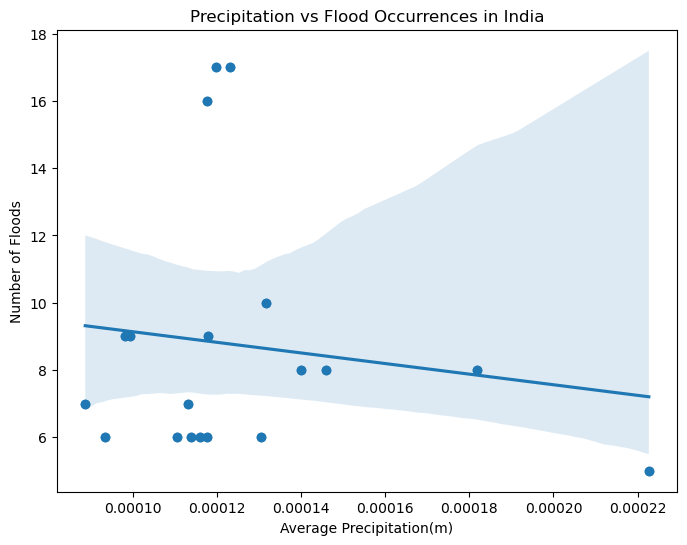

In [38]:
# plotting link between precipitation and floods in India
# --- whole of india comparison --- 
df_floods = df_EMDAT[
    (df_EMDAT["Country"] == "India") &
    (df_EMDAT['Disaster Type'] == "Flood")
]

floods_per_year = df_floods.groupby("Start Year").size()
floods_per_year = floods_per_year.reset_index(name = "Flood Count")

precipitation_per_year = df_METOFFICE.groupby("Year")["Precipitation"].mean().reset_index()

combined = pd.merge(
    precipitation_per_year,
    floods_per_year,
    left_on="Year",
    right_on="Start Year",
    how="inner"
)

plt.figure(figsize=(8, 6))
plt.scatter(combined["Precipitation"], combined["Flood Count"])
sns.regplot(x="Precipitation", y="Flood Count", data=combined)

plt.xlabel("Average Precipitation(m)")
plt.ylabel("Number of Floods")
plt.title("Precipitation vs Flood Occurrences in India")
plt.show()


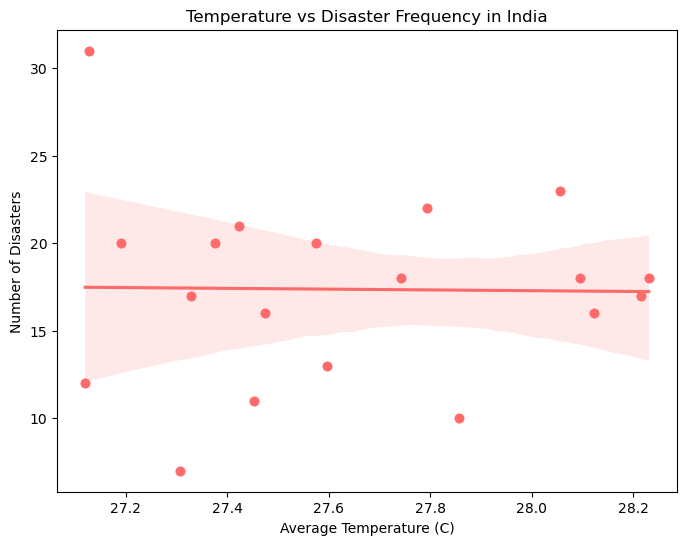

Text(0.5, 1.0, 'Temperature and Disaster Trends Over Time in India')

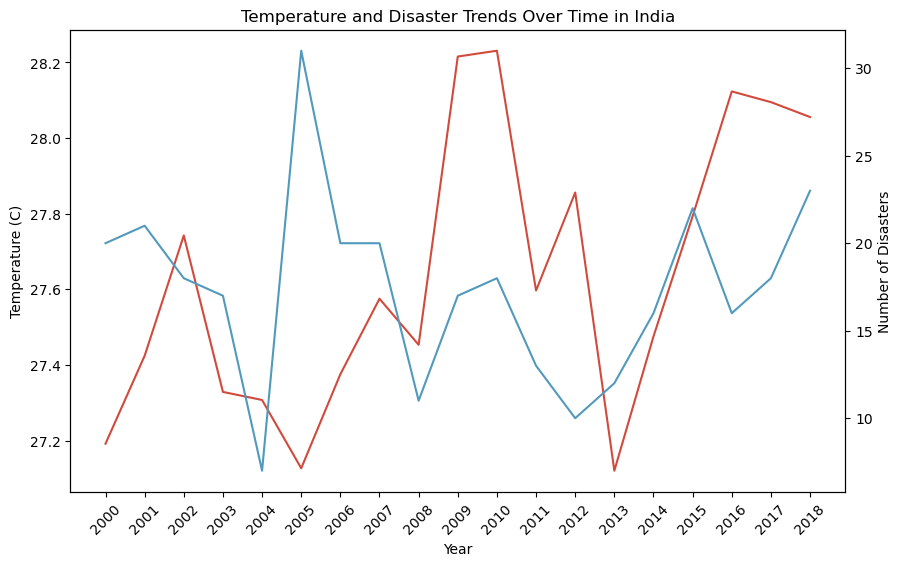

In [22]:
# looking into disasters and temperature, generalised to all types of disasters
# --- scatter plot ---
df_india = df_EMDAT[df_EMDAT["Country"] == "India"]
disasters_per_year = df_india.groupby("Start Year").size().reset_index(name="Disaster Count")

temperature_per_year = df_METOFFICE.groupby("Year")["Temperature_C"].mean().reset_index()

combined = pd.merge(
    temperature_per_year, 
    disasters_per_year,
    left_on="Year",
    right_on="Start Year",
    how="inner"
)

plt.figure(figsize=(8,6))
plt.scatter(combined["Temperature_C"], combined["Disaster Count"], color="#FF6B6B")
sns.regplot(x="Temperature_C", y="Disaster Count", data=combined, color="#FF6B6B")

plt.xlabel("Average Temperature (C)")
plt.ylabel("Number of Disasters")
plt.title("Temperature vs Disaster Frequency in India")
plt.show()

# --- dual-axis line plot (all disasters) --- 
fig, ax1 = plt.subplots(figsize=(10, 6))

years = combined["Year"]

ax1.plot(years, combined["Temperature_C"], color="#d14a3b")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature (C)")
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(years, combined["Disaster Count"], color="#5199bd")
ax2.set_ylabel("Number of Disasters")
ax2.tick_params(axis="y")

plt.title("Temperature and Disaster Trends Over Time in India")

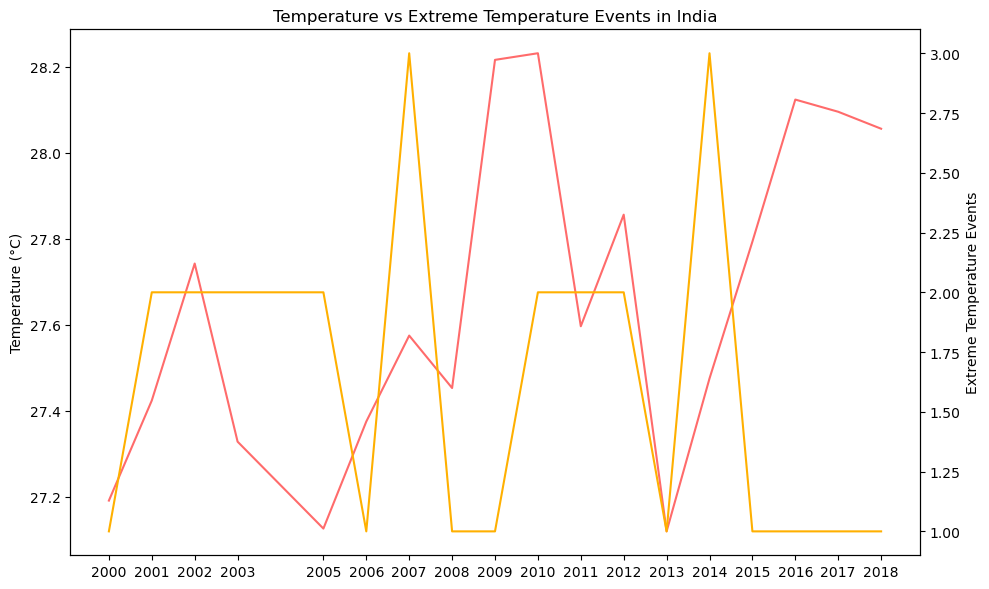

In [ ]:
# findings links between temperature and the number of extreme temperature disasters
df_temp_extreme = df_EMDAT[
    (df_EMDAT["Country"] == "India") &
    (df_EMDAT["Disaster Type"] == "Extreme temperature")
]

temp_extreme_per_year = df_temp_extreme.groupby("Start Year").size().reset_index(name="Extreme Temp Events")
temperature_per_year = df_METOFFICE.groupby("Year")["Temperature_C"].mean().reset_index()

combined_extreme = pd.merge(
    temperature_per_year,
    temp_extreme_per_year,
    left_on="Year",
    right_on="Start Year",
    how="inner"
)

combined_extreme["Extreme Temp Events"] = combined_extreme["Extreme Temp Events"].fillna(0)

fig, ax1 = plt.subplots(figsize=(10,6))

years = combined_extreme["Year"]

ax1.plot(years, combined_extreme["Temperature_C"], color="#FF6B6B")
ax1.set_ylabel("Temperature (°C)")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(years, combined_extreme["Extreme Temp Events"], color="#FFB000")
ax2.set_ylabel("Extreme Temperature Events")
ax2.tick_params(axis="y")

plt.xticks(years, rotation=45)
plt.title("Temperature vs Extreme Temperature Events in India")
plt.tight_layout()
plt.show()